## Import libraries

In [ ]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import reprojection_consistency_score
import h5py
import numpy as np
from skimage.transform import pyramid_gaussian
from scipy.ndimage import zoom

def tomo_data(file,redo_align=False):
    try:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    except KeyError:
        with h5py.File(file) as hf:
            projs = hf['data'][...]
            angles = hf['angles'][...]
    angles = angles * np.pi / 180
    #Shift angles to be centered around 0
    angles = angles - np.mean(angles)
    return projs, angles


## Import real Data

In [ ]:
import os

downsample = 4
recon_alg = 'gridrec'
filename = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
# filename = "/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5"

cached_filename = filename.replace(".hdf5", f"_ds{downsample}.hdf5")

if os.path.exists(cached_filename):
    print(f"Loading downsampled cache: {cached_filename}")
    projections, angles = tomo_data(cached_filename)
    print(projections.shape)
    tomo = tomoData(projections, angles)
else:
# if True:
    print("Cache not found — loading full dataset...")
    projections_og, angles = tomo_data(filename, redo_align=True)
    print("Full dataset shape:", projections_og.shape)

    #Remove projection and angle 26
    projections_og = np.delete(projections_og, 26, axis=0)
    angles = np.delete(angles, 26)

    #Remove projection and angle 19
    projections_og = np.delete(projections_og, 19, axis=0)
    angles = np.delete(angles, 19)
    _needs_downsample = True

if not os.path.exists(cached_filename):
# if True:
    print("Downsampling...")
    projections = zoom(projections_og, (1, 1/downsample, 1/downsample), order=1)
    print(projections.shape)

    print(f"Saving downsampled cache to: {cached_filename}")
    with h5py.File(cached_filename, 'w') as hf:
        hf.create_dataset('data', data=projections)
        hf.create_dataset('angles', data=angles * 180 / np.pi)  # save back in degrees

    tomo = tomoData(projections, angles)

num_angles = projections.shape[0] if os.path.exists(cached_filename) else projections_og.shape[0]
print(f"Number of angles: {num_angles}")

Cache not found — loading full dataset...
Full dataset shape: (558, 585, 1810)
Downsampling...
(556, 146, 452)
Saving downsampled cache to: /Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2_ds4.hdf5
Number of angles: 556


In [3]:
print(angles* 180/np.pi)
(180-(71.99+58.80))/180

[-7.19951267e+01 -7.17952912e+01 -7.15954557e+01 -7.13956202e+01
 -7.09959492e+01 -7.07950158e+01 -7.05951803e+01 -7.03964428e+01
 -7.01955093e+01 -6.99956738e+01 -6.97958383e+01 -6.93950693e+01
 -6.91952339e+01 -6.89953984e+01 -6.87955629e+01 -6.85957274e+01
 -6.83958919e+01 -6.81949584e+01 -6.77963854e+01 -6.73956165e+01
 -6.71957810e+01 -6.69970435e+01 -6.68005020e+01 -6.65951765e+01
 -6.62004465e+01 -6.57958346e+01 -6.55949011e+01 -6.53950656e+01
 -6.51963281e+01 -6.49953946e+01 -6.45957236e+01 -6.43969861e+01
 -6.41949547e+01 -6.39951192e+01 -6.37952837e+01 -6.35954482e+01
 -6.33956127e+01 -6.29959417e+01 -6.27950082e+01 -6.25962708e+01
 -6.23953373e+01 -6.21955018e+01 -6.19956663e+01 -6.17969288e+01
 -6.13950618e+01 -6.11946773e+01 -6.09953909e+01 -6.07955554e+01
 -6.05957199e+01 -6.03958844e+01 -6.01949509e+01 -5.97952799e+01
 -5.95954444e+01 -5.93950599e+01 -5.91957735e+01 -5.89953890e+01
 -5.85946200e+01 -5.81954980e+01 -5.79956625e+01 -5.77952780e+01
 -5.75959916e+01 -5.73961

0.27338888888888896

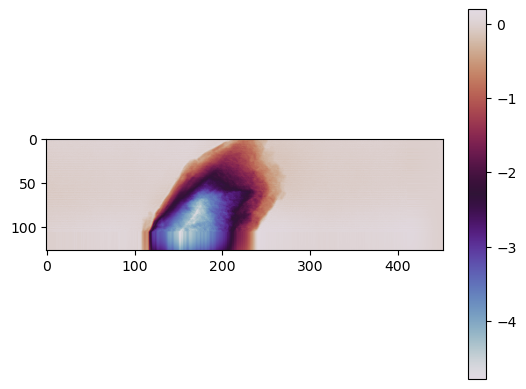

In [4]:
from helperFunctions import subpixel_shift
imageToShift = tomo.workingProjections[0,20:,::]
shiftedImage = subpixel_shift(imageToShift, shift_y=-20, shift_x=-40)

import matplotlib.pyplot as plt
plt.imshow(shiftedImage, cmap='twilight')
plt.colorbar()
plt.show()

In [5]:
print(projections.shape)
tomo.makeNotebookProjMovie()

(556, 146, 452)


Output()

## Align Data

In [6]:
# # Show bad reconstruction prior to alignment
# tomo.reset_workingProjections(x_size=None, y_size=None) #You can adjust these for tighter cropping
# tomo.normalize(isPhaseData=True)

# tomo.reconstruct(algorithm=recon_alg)
# print("\nBad reconstruction prior to alignment")
# badRecon = tomo.recon.copy()
# MoviePlotter(badRecon)

In [7]:
# # Reprojection Consistency Score — before alignment
# rcs_before, _, _ = tomo.reprojection_consistency_score(plot=False)

# #Sinogram consistency score — before alignment
# scs_before, _, _, _, _ = tomo.sinogram_consistency_score(plot=False)



Normalizing projections


Cross-Correlation Alignment  [4x downsample | full frame | gradient mode]


Iteration 1/10: 100%|██████████| 555/555 [00:08<00:00, 63.81it/s] 


  Projection 278 shift: y=3.8400 px, x=-28.8000 px


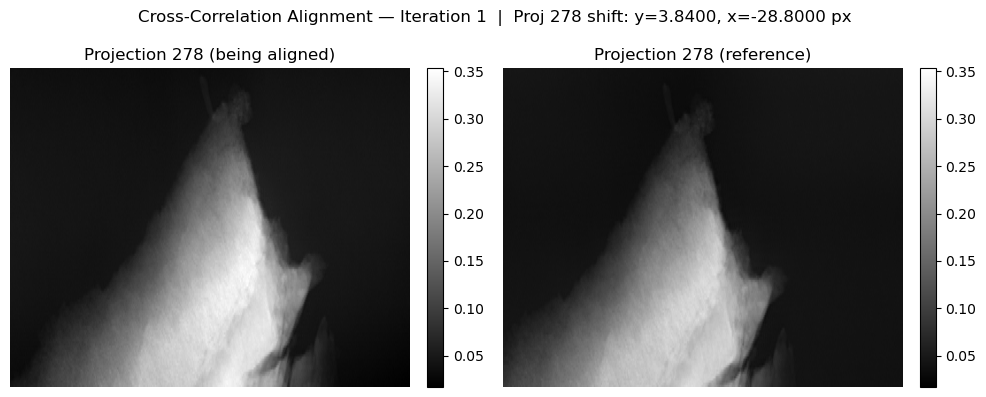

Iteration 1: avg shift = 16.6843 px, max shift = 83.2301 px


Iteration 2/10: 100%|██████████| 555/555 [00:12<00:00, 44.25it/s]


Iteration 2: avg shift = 3.2969 px, max shift = 16.4831 px


Iteration 3/10: 100%|██████████| 555/555 [00:13<00:00, 39.87it/s]


Iteration 3: avg shift = 0.6138 px, max shift = 6.4180 px


...

Iteration 9/10: 100%|██████████| 555/555 [00:04<00:00, 112.41it/s]


Iteration 9: avg shift = 0.0619 px, max shift = 3.1759 px


Iteration 10/10: 100%|██████████| 555/555 [00:04<00:00, 123.90it/s]


Iteration 10: avg shift = 0.0508 px, max shift = 0.8616 px
Maximum iterations reached without convergence.
Largest shifts per direction:
  Top    (down  39.20 px) — projection 432
  Bottom (up    18.40 px) — projection 459
  Left   (right 60.32 px) — projection 404
  Right  (left  111.36 px) — projection 264


Output()

In [8]:
#Initialize and do bulk move
tomo.reset_workingProjections(x_size=None, y_size=None)
tomo.normalize(isPhaseData=True)

# Pass 1 — full frame, no ROI
tomo.cross_correlate_align(
    tolerance=0, maxShiftTolerance=0,
    yROI_Range=None, xROI_Range=None, isFull360=False,
    downsample=4, max_iterations=10, stepRatio=0.8, use_grad=True, plot=True
)
tomo.makeNotebookProjMovie(show_trust_region=True)


XCA ROI — y: [7, 124]  x: [102, 349]


Cross-Correlation Alignment  [2x downsample | ROI y=[  7 124] x=[102 349] | gradient mode]


Iteration 1/10: 100%|██████████| 555/555 [00:03<00:00, 175.77it/s]


  Projection 278 shift: y=0.0000 px, x=0.0000 px


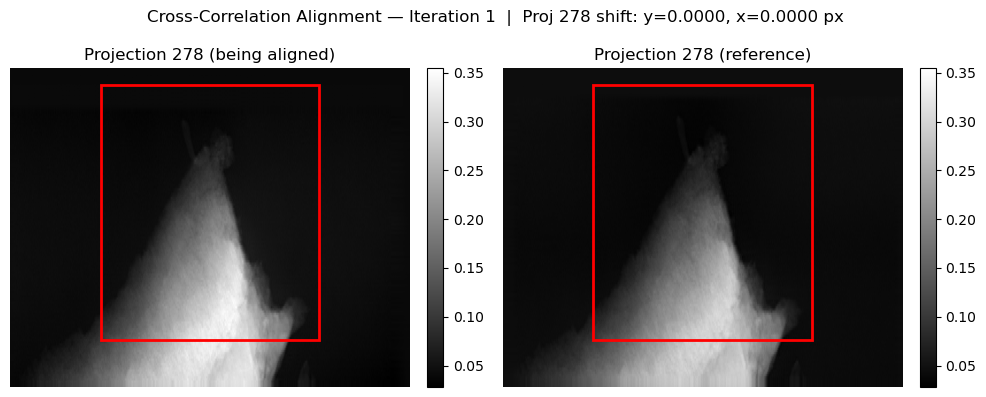

Iteration 1: avg shift = 0.3931 px, max shift = 7.6340 px


Iteration 2/10: 100%|██████████| 555/555 [00:05<00:00, 99.74it/s] 


Iteration 2: avg shift = 0.1125 px, max shift = 3.2800 px


Iteration 3/10: 100%|██████████| 555/555 [00:04<00:00, 114.84it/s]


Iteration 3: avg shift = 0.0609 px, max shift = 3.7947 px


...

Iteration 9: avg shift = 0.0202 px, max shift = 0.3200 px


Iteration 10/10: 100%|██████████| 555/555 [00:03<00:00, 138.84it/s]


Iteration 10: avg shift = 0.0124 px, max shift = 0.1600 px
Maximum iterations reached without convergence.


Cross-Correlation Alignment  [full resolution | ROI y=[  7 124] x=[102 349] | gradient mode]


Iteration 1/5: 100%|██████████| 555/555 [00:02<00:00, 196.39it/s]


  Projection 278 shift: y=0.0000 px, x=0.0000 px


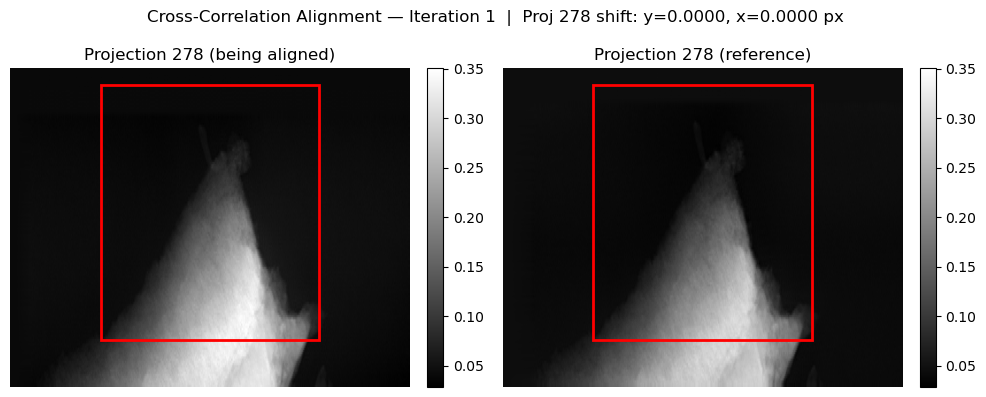

Iteration 1: avg shift = 0.1423 px, max shift = 7.5942 px


Iteration 2/5: 100%|██████████| 555/555 [00:03<00:00, 147.07it/s]


Iteration 2: avg shift = 0.0817 px, max shift = 3.2410 px


Iteration 3/5: 100%|██████████| 555/555 [00:03<00:00, 174.48it/s]


Iteration 3: avg shift = 0.0536 px, max shift = 2.4403 px


Iteration 4/5: 100%|██████████| 555/555 [00:03<00:00, 168.93it/s]


Iteration 4: avg shift = 0.0384 px, max shift = 2.5603 px


Iteration 5/5: 100%|██████████| 555/555 [00:02<00:00, 237.62it/s]


Iteration 5: avg shift = 0.0254 px, max shift = 0.5614 px
Maximum iterations reached without convergence.


Projection Matching Alignment (PMA) [optical_flow | matching_preprocess]
Centering Projections
Original center: 257.5
Center of frame: 226
Aligned projections shifted by -31.5 pixels
Projections are currently centered at pixel 226.0. Residual offset: 0.0

--- PMA Level 2 (4x downsampled, 2 iterations) ---


PMA Level 2 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

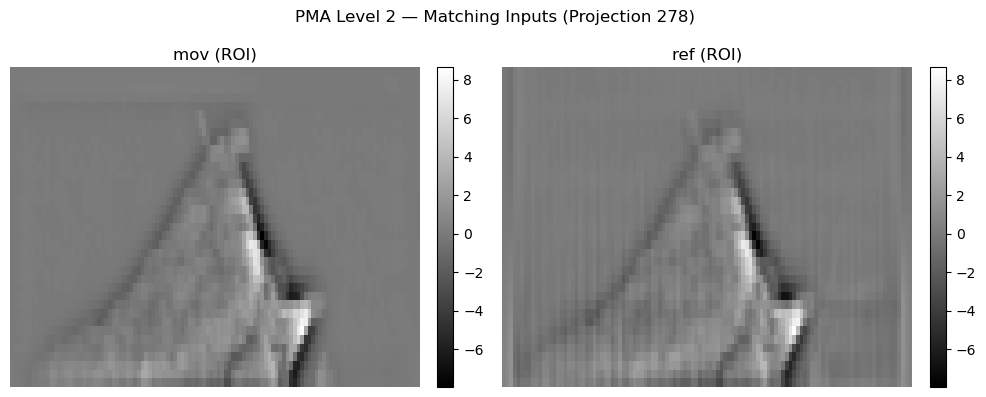

PMA Level 2 iterations:  50%|█████     | 1/2 [00:04<00:04,  4.44s/it]

Iteration 1: avg shift = 0.3389 px, max shift = 2.0865 px


PMA Level 2 iterations: 100%|██████████| 2/2 [00:08<00:00,  4.12s/it]

Iteration 2: avg shift = 0.2263 px, max shift = 1.2726 px

--- PMA Level 1 (2x downsampled, 2 iterations) ---



PMA Level 1 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

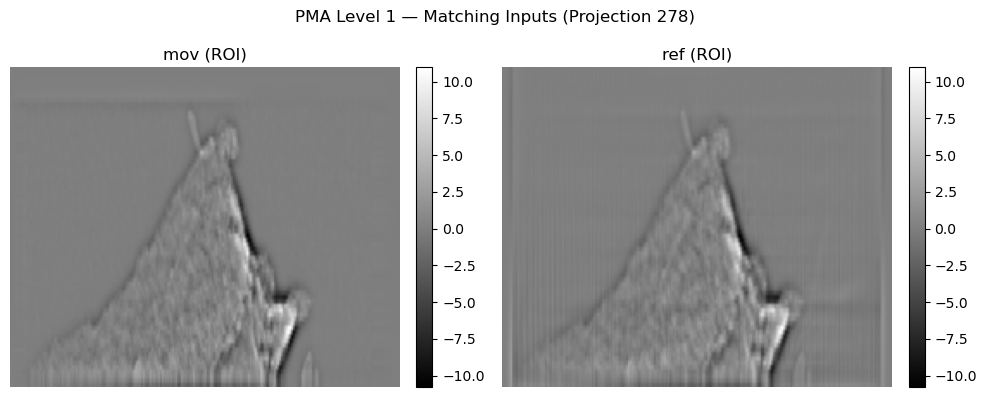

PMA Level 1 iterations:  50%|█████     | 1/2 [00:11<00:11, 11.19s/it]

Iteration 1: avg shift = 0.0881 px, max shift = 0.4864 px


PMA Level 1 iterations: 100%|██████████| 2/2 [00:21<00:00, 10.73s/it]

Iteration 2: avg shift = 0.0736 px, max shift = 0.4186 px

--- PMA Level 0 (1x downsampled, 2 iterations) ---



PMA Level 0 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

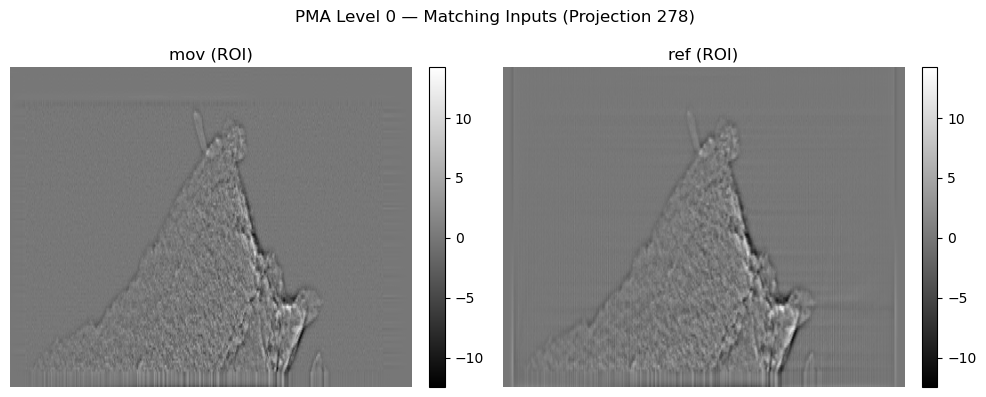

PMA Level 0 iterations:  50%|█████     | 1/2 [00:57<00:57, 57.35s/it]

Iteration 1: avg shift = 0.0377 px, max shift = 0.1663 px


PMA Level 0 iterations: 100%|██████████| 2/2 [01:54<00:00, 57.38s/it]

Iteration 2: avg shift = 0.0295 px, max shift = 0.1466 px



PMA complete.


Apply shifts to final projections: 100%|██████████| 556/556 [00:07<00:00, 74.69it/s]


In [9]:
# Compute ROI for passes 2+ (matches hyperparameter_search.py compute_roi formula)
H = tomo.workingProjections.shape[1]
W = tomo.workingProjections.shape[2]
lb = 0.85  # lower-bound crop percentage for y-ROI
edge = 200 // downsample
inner = W - 2 * edge
xca_yROI = np.array([int(0.05 * H), int(lb * H)])
xca_xROI = np.array([edge + int(0.15 * inner), edge + int(0.85 * inner)])
print(f"XCA ROI — y: {xca_yROI.tolist()}  x: {xca_xROI.tolist()}")

# Pass 2
tomo.cross_correlate_align(
    tolerance=0, maxShiftTolerance=0,
    yROI_Range=xca_yROI, xROI_Range=xca_xROI, isFull360=False,
    downsample=2, max_iterations=10, stepRatio=0.8, use_grad=True, plot=True,
)

# Pass 3
tomo.cross_correlate_align(
    tolerance=0, maxShiftTolerance=0,
    yROI_Range=xca_yROI, xROI_Range=xca_xROI, isFull360=False,
    downsample=1, max_iterations=5,  stepRatio=0.8, use_grad=True, plot=True,
)

# PMA — 3-level pyramid, scale=2, [5, 5, 5] iters, sigma=2.0
tomo.PMA(
    tolerance=0, algorithm=recon_alg, plot=True,
    levels=3,
    scale=2,
    iterations_per_level=[2, 2, 2],
    shift_method='optical_flow',
    of_sigma=2.0,
    stepRatio=0.8,
)

tomo.make_updates_shift()
# tomo.makeNotebookProjMovie(show_trust_region=True)


In [10]:
tomo.makeNotebookProjMovie()
tomo.reconstruct(algorithm=recon_alg)
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

Output()



Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Good Reconstruction after alignment


Output()

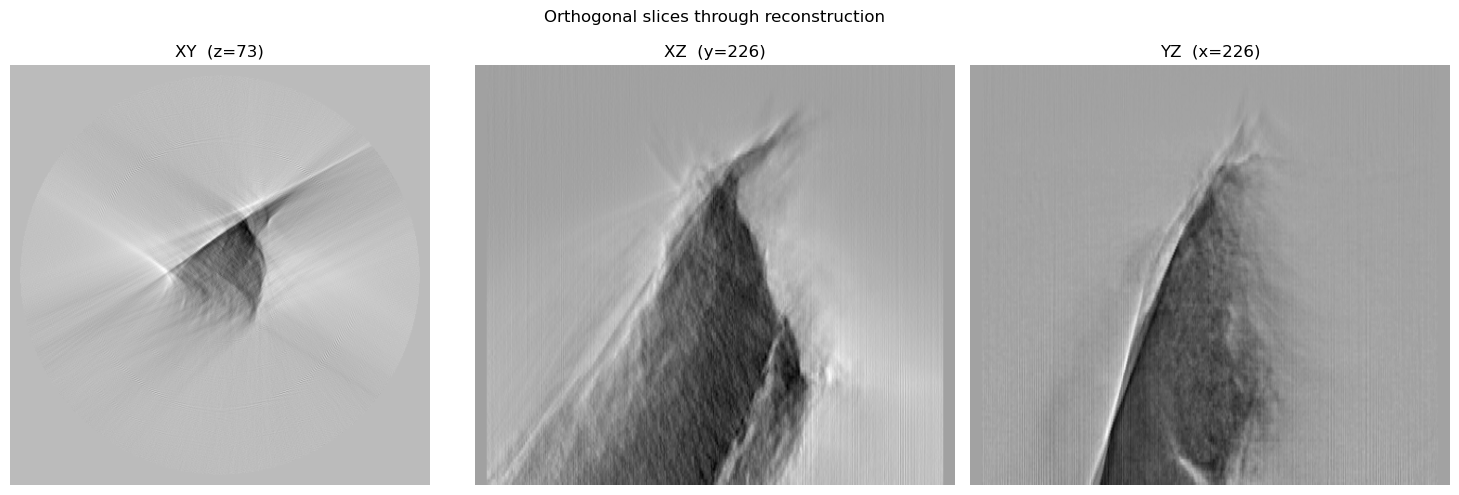

In [11]:
tomo.displayReconOrthogonalSlices()



Computing reprojections of reconstruction...
Computing per-angle NRMSE...


NRMSE per angle: 100%|██████████| 556/556 [00:00<00:00, 2509.92it/s]



─── Reprojection Consistency Score ───────────────────────
  RCS (mean NRMSE):   0.5984
  Best  angle [ 546]:  NRMSE = 0.1096
  Worst angle [ 240]:  NRMSE = 1.2777
  Std across angles:  0.2022
  Verdict:  ✗  Poor — significant misalignment or reconstruction failure.
───────────────────────────────────────────────────────────



/Users/levihancock/Documents/Work/Code/TomoMono/alignment_methods.py:1256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


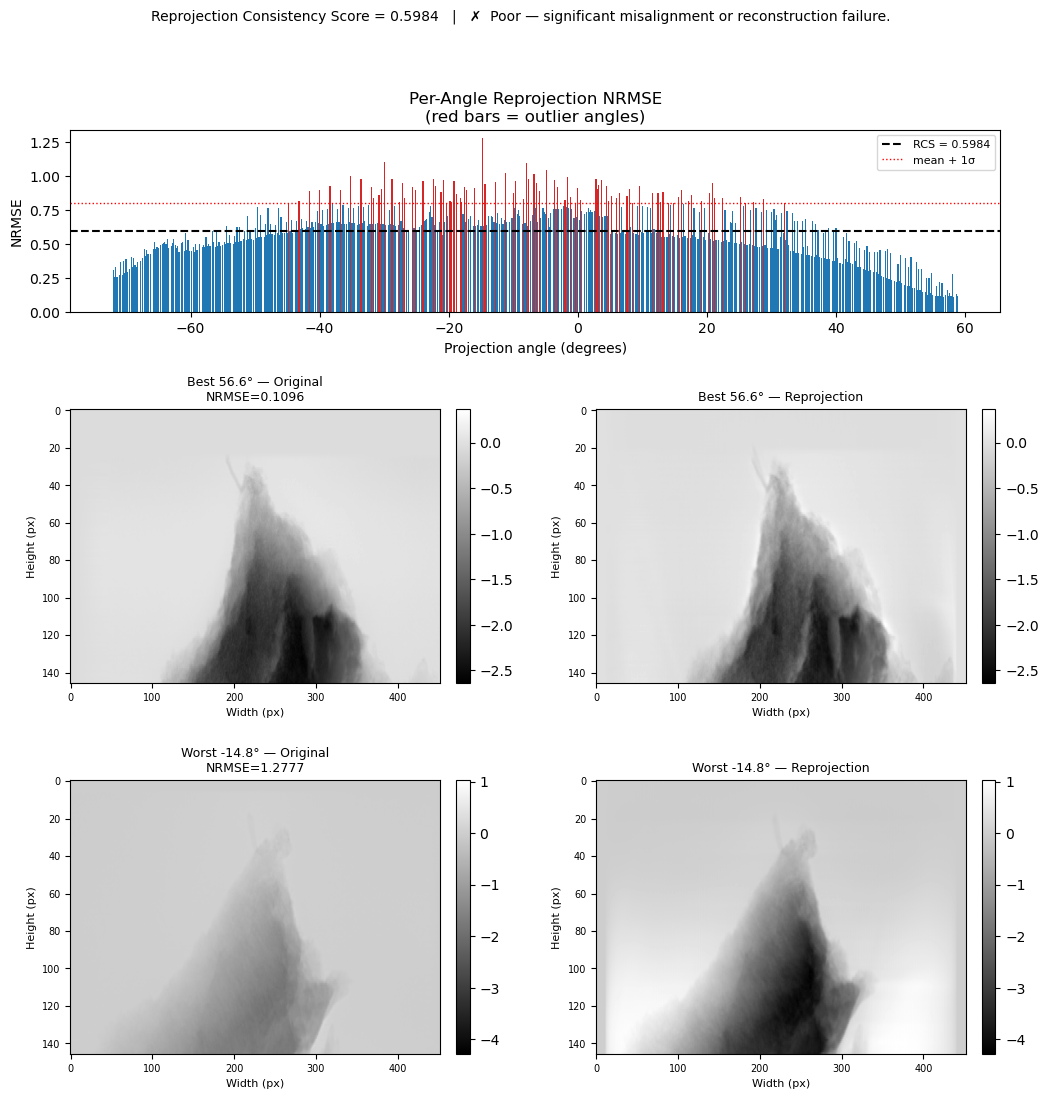



Sinogram consistency:
  x_cm (horizontal) — RMSE: 3.3866 px  |  R²: 0.917390
  y_cm (vertical)   — RMSE: 3.3636 px  |  R²: 0.000000
  Combined RMSE:       3.3751 px


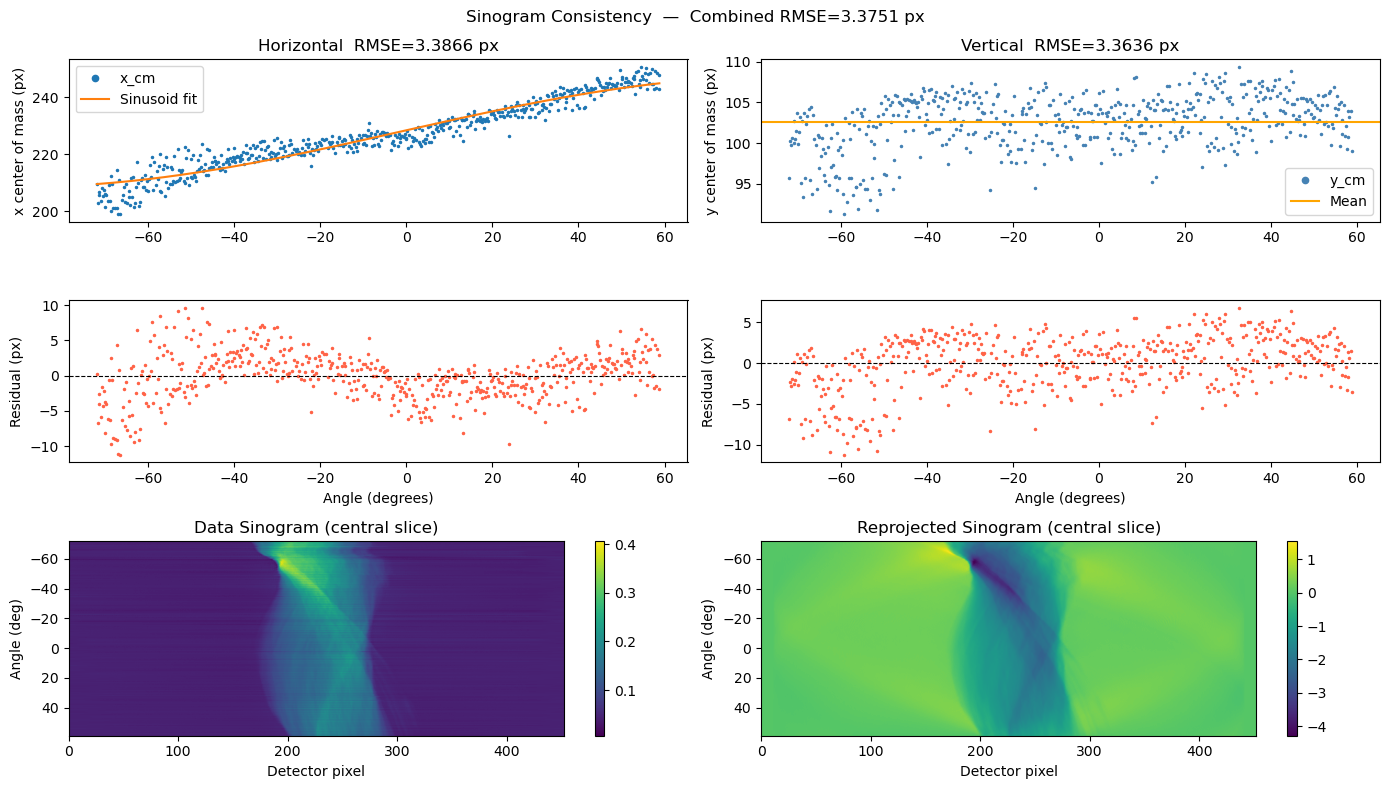

In [12]:
# Reprojection Consistency Score — after alignment
rcs_after, _, _ = tomo.reprojection_consistency_score(plot=True)

#Sinogram consistency score — after alignment
scs_after, _, _, _, _ = tomo.sinogram_consistency_score(plot=True)

# # print("=" * 52)
# # print("  ALIGNMENT QUALITY SUMMARY")
# # print("=" * 52)
# # print(f"  {'Metric':<22} {'Before':>8} {'After':>8} {'Δ':>10}")
# # print(f"  {'-'*50}")
# # print(f"  {'RCS (lower = better)':<22} {rcs_before:>8.4f} {rcs_after:>8.4f} {rcs_before - rcs_after:>+10.4f}")
# # print("=" * 52)

In [13]:
# import tifffile
# tifffile.imwrite("reconstruction(downsampled).tiff", tomo.recon.astype("float32"))

In [ ]:
reprojections = tomo.simulateProjections()

MoviePlotter(reprojections)

In [15]:
tomo.final_projections = tomo.workingProjections.copy()
tomo.reconstruct(algorithm=recon_alg)
print("\nGood Reconstruction after alignment with working projections")
tomo.makeNotebookReconMovie()



Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Good Reconstruction after alignment with working projections


Output()

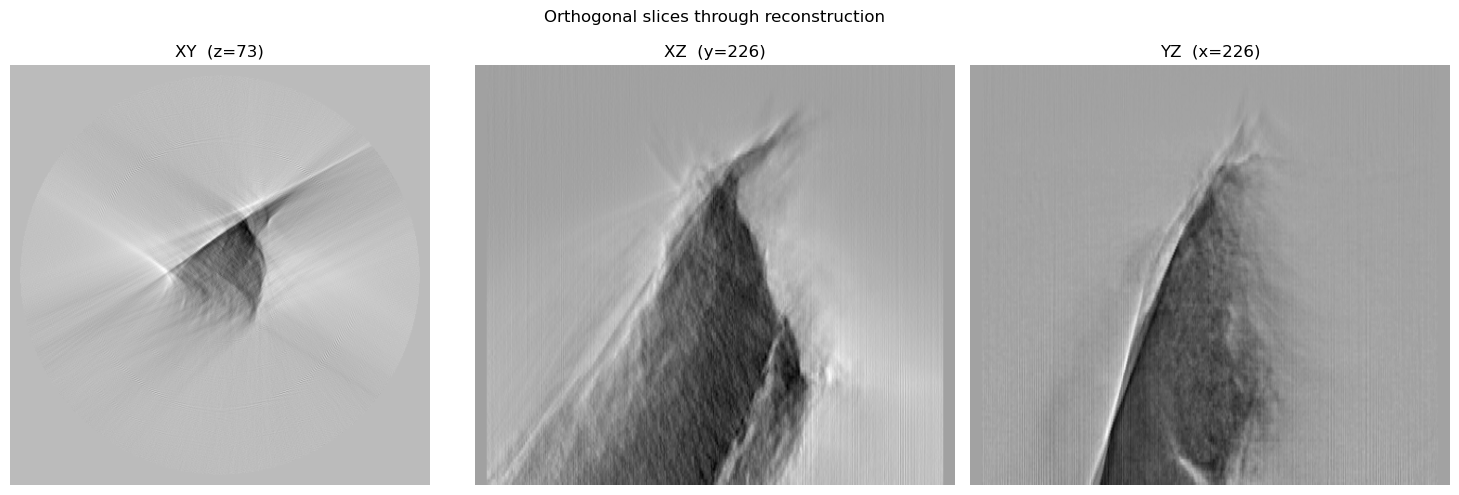

In [16]:
tomo.displayReconOrthogonalSlices()